<h1 style="color: #336699;"><b>ELIXIR Spatial course</b></h1>

<h2 style="color: #336699;">Practical 6: Multi-slice spatial data integration (part 1)</h2>

<h4>8th October 2026</h4>
<h4>Benedetta Manzato, Emma Vonk (Leiden University Medical Center)</h4>

<div style="border: 2px solid #336699; padding: 15px; border-radius: 8px;">
  <span style="color: #336699; font-size: 24px; font-weight: bold;">Agenda:</span>
  <ol style="margin-top: 10px; padding-left: 25px; font-size: 17px; color: #333333;">
    <li>Uni-modal slides alignment with MOSCOT</li>

  </ol>
</div>



In [ ]:
import os
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import squidpy as sq
from moscot.problems.space import AlignmentProblem
from PIL import Image

warnings.filterwarnings("ignore")

#### Uni-modal dataset: 10X Visium Mouse Brain Coronal

<font size="3"> Preprocessed sections can be found on [Zenodo](https://zenodo.org/records/22917113)

<font size="3"> For reference, you can find the (raw) sections here: [section 1](https://www.10xgenomics.com/datasets/mouse-brain-coronal-section-1-ffpe-2-standard) and [section 2](https://www.10xgenomics.com/datasets/mouse-brain-coronal-section-2-ffpe-2-standard). 



### Read data 


In [ ]:
# Set up paths
base_dir = "../data/Practical6_1/data/"

image_files = [
    f"{base_dir}/tissue_hires_image_1.png",
    f"{base_dir}/tissue_hires_image_2.png"
]
moldata_files = [
    f"{base_dir}/coronal_1.h5ad",
    f"{base_dir}/coronal_2.h5ad"
]

<font size="3"> Inspect your images:

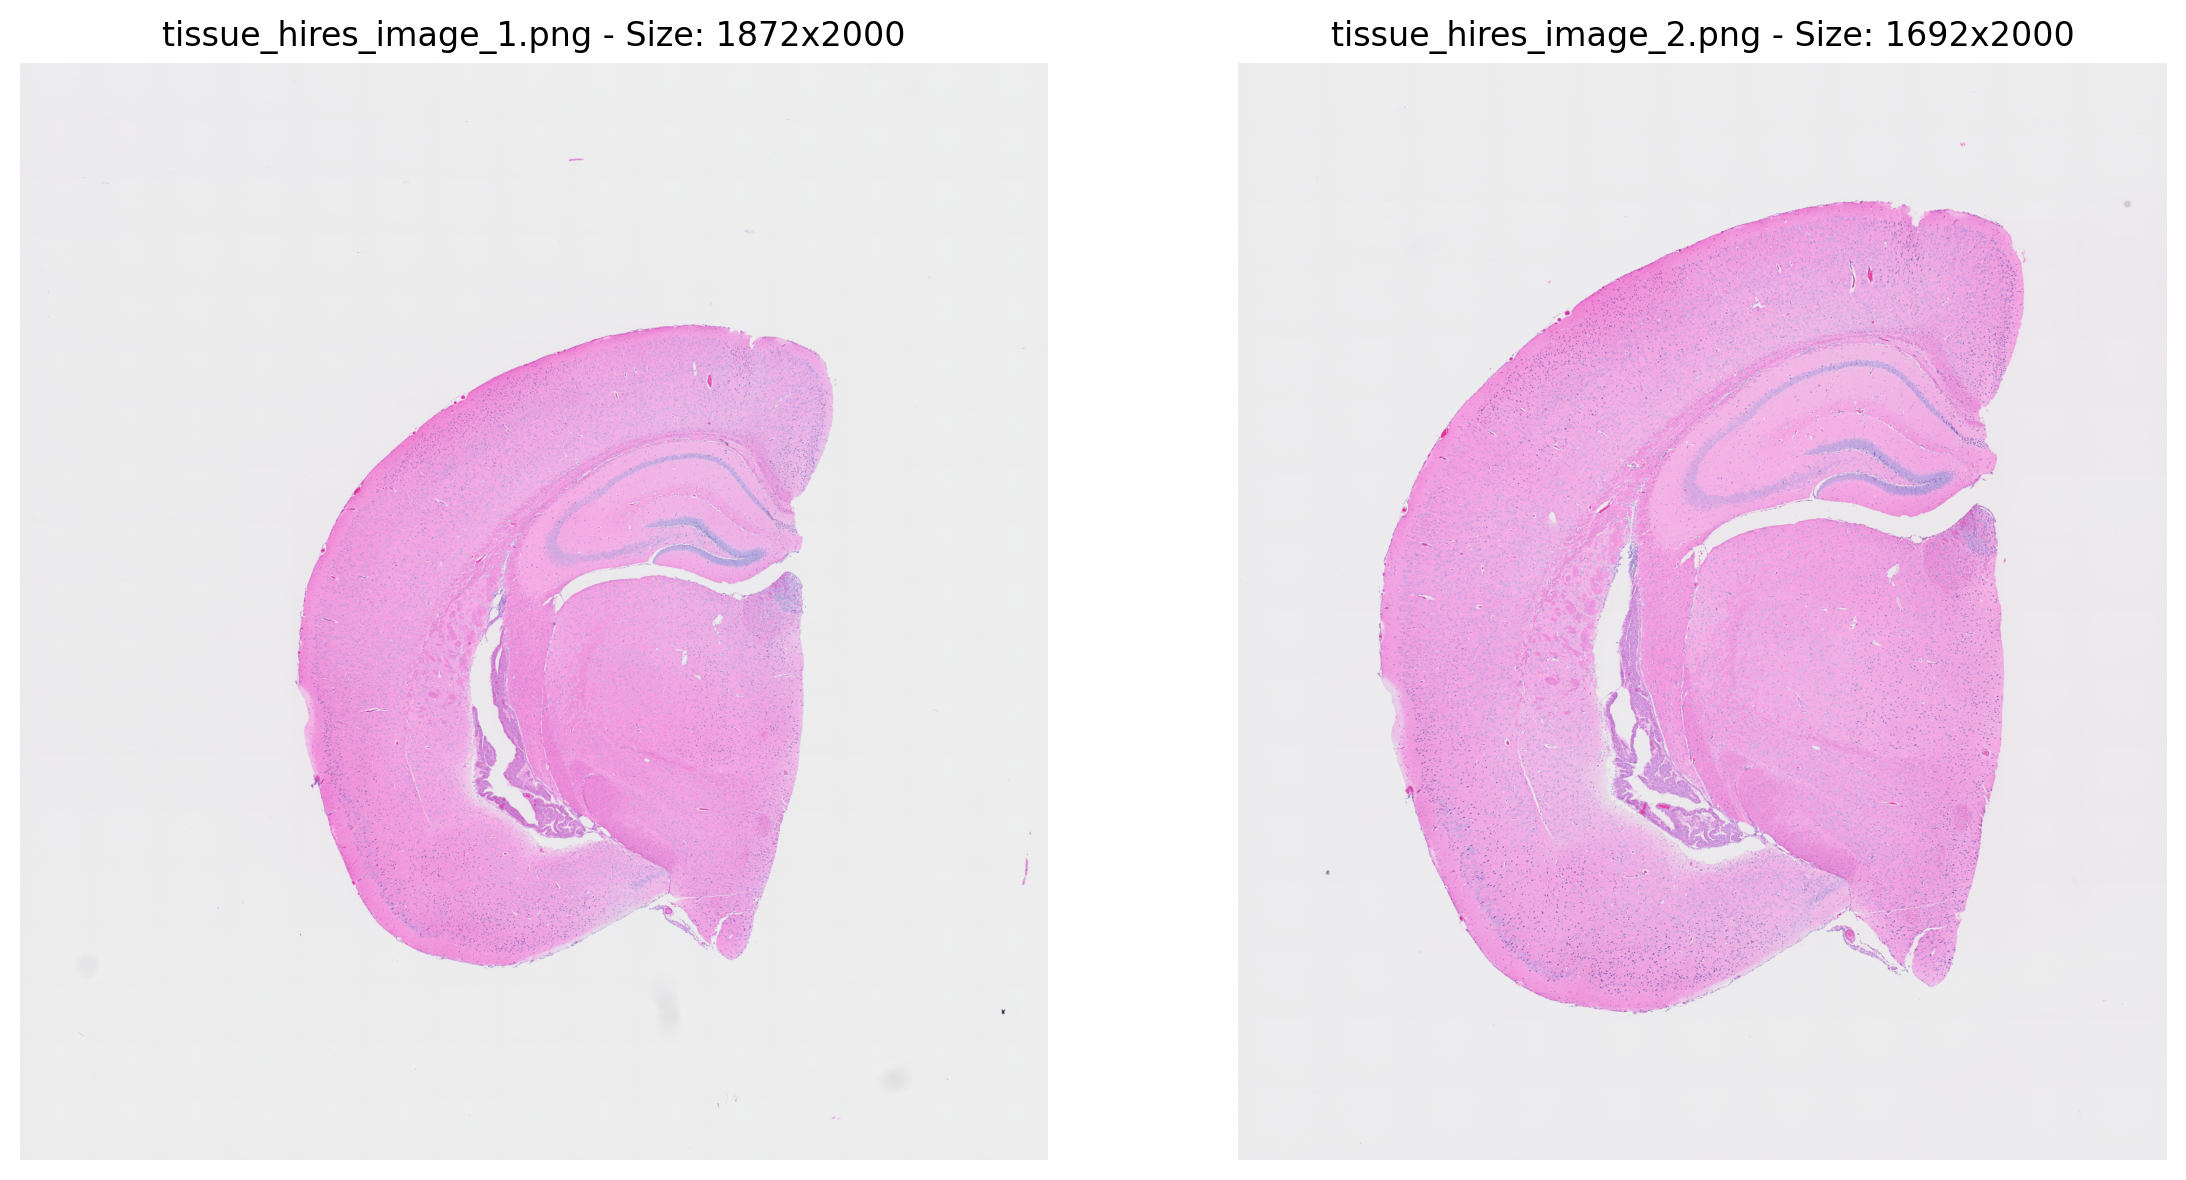

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=200)

for ax, img_path in zip(axes, image_files):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"{os.path.basename(img_path)} - Size: {img.size[0]}x{img.size[1]}", fontsize=12)

plt.tight_layout()
plt.show()

<font size="3"> Make sure that the coordinate file and the images are in the same coordinate framework: plot images with coordinates overlaid

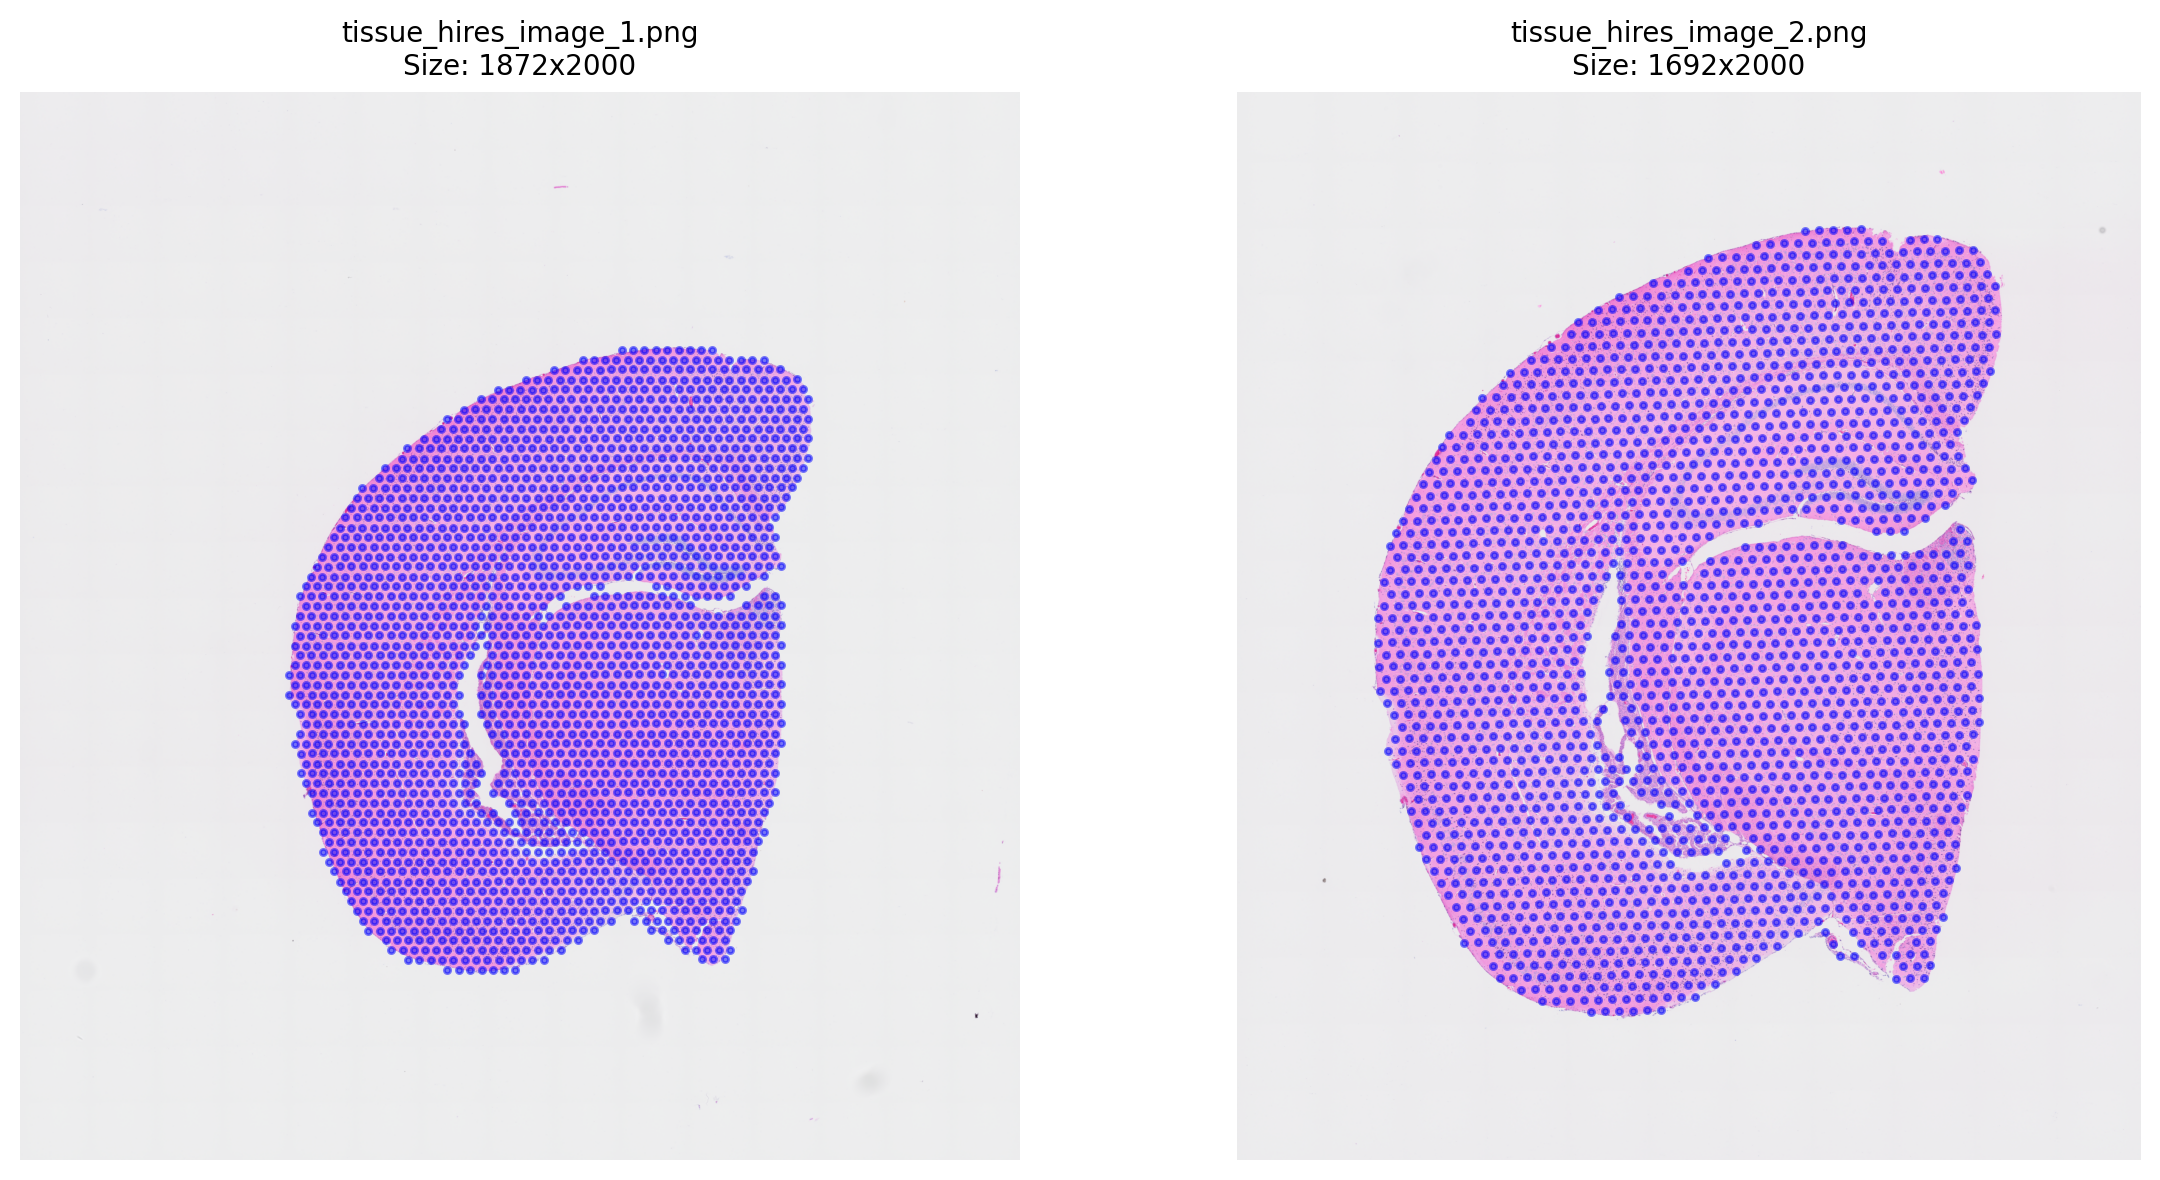

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=200)

for ax, img_path, h5ad_path in zip(axes, image_files, moldata_files):
    img = Image.open(img_path)

    adata = sc.read_h5ad(h5ad_path)
    df = adata.obs[['x', 'y']].copy()

    ax.imshow(img)
    ax.scatter(df['x'], df['y'], s=5, c='blue', alpha=0.5)
    ax.axis('off')
    ax.set_title(f"{os.path.basename(img_path)}\nSize: {img.size[0]}x{img.size[1]}", fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
import gc

# collect garbage
gc.collect()

5905

## 1. Uni-modal alignment using MOSCOT
[Search and match across spatial omics samples at single-cell resolution (Klein et al. 2025)](https://www.nature.com/articles/s41586-024-08453-2)

https://moscot.readthedocs.io/en/latest/notebooks/tutorials/300_spatial_alignment.html

<figure>
    <img src="https://raw.githubusercontent.com/theislab/moscot/main/docs/_static/img/light_mode_concept_revised.png" width="700" height="280" alt="MOSCOT conceptual workflow diagram">
    <figcaption>From <a href="https://www.nature.com/articles/s41586-024-08453-2" target="_blank">Klein et al. (2025)</a></figcaption>
</figure>

In [8]:
# Load data
adata1 = ad.read_h5ad(f'{base_dir}/coronal_1.h5ad')
adata2 = ad.read_h5ad(f'{base_dir}/coronal_2.h5ad')

adata1.obs['sample'] = 'section1'
adata2.obs['sample'] = 'section2'

# Define a cleanup function to fix .var duplicates
def prepare_adata(adata, name):
    if adata.var.index.duplicated().any():
        print(f"Found duplicate gene names in {name}. Fixing now...")
        adata.var_names_make_unique() # This appends '-1', '-2' etc. to duplicate gene names
    return adata

# Apply to both
adata1 = prepare_adata(adata1, 'section1')
adata2 = prepare_adata(adata2, 'section2')

# 3. Concatenate using index_unique to handle .obs collision
adata = ad.concat(
    [adata1, adata2], 
    keys=['sec1', 'sec2'], 
    index_unique='_'
)

adata.layers['norm_1e4'] = sc.pp.normalize_total(adata, target_sum=1e4, inplace=False)['X'].toarray() # we use normalized counts for each cell as input gene expression

Found duplicate gene names in section1. Fixing now...
Found duplicate gene names in section2. Fixing now...


In [9]:
adata.obsm['spatial'] = np.column_stack([adata.obs['x'], adata.obs['y']])

<font size="3"> Visualize datasets coordinate before alignment:

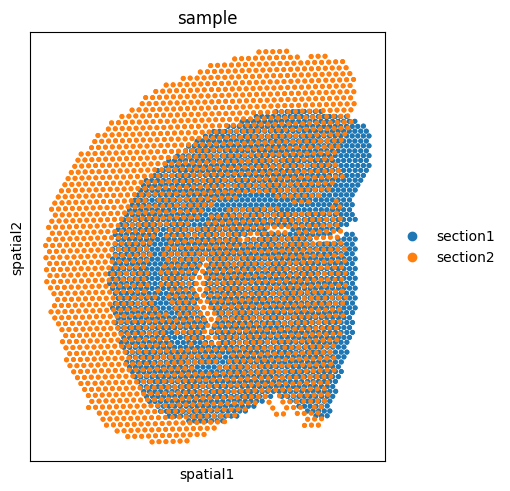

In [10]:
sq.pl.spatial_scatter(adata, shape=None, library_id="sample", color="sample")

<font size="3"> With moscot, it is possible to learn a cross-dataset mapping by leveraging Fused Gromov-Wasserstein (FGW) optimal transport [Vayer et al., 2018]. A basic description of the algorithm is the following:

<font size="3"> Given a set of observations that share some features in the metric space, and some other features in different metric spaces, the FGW method aims at finding the optimal matching between these two set of observations, based on both shared and unique features. In our case:

- <font size="3"> the “shared” metric space could be the one defined by a set of genes that is measured across spatial transcriptomics data.

- <font size="3"> the “unique” metric spaces are the spatial coordinates, which are unique for each single slide.

#### Prepare the AlignmentProblem
<font size="3"> The AlignmentProblem exposes the FGW algorithm in a user-friendly API. First, we need to prepare() the problem. In this particular case, we need to pay attention to the policy parameter. The available policies are:

<font size="3"> 'star': if we wish to align all slides to a reference slide.

<font size="3"> 'sequential' (default): if we wish to align each slide to the subsequent one, in case we have a sequence of slides.

<font size="3"> The choice of the policy varies with the use cases, for the sake of this tutorial we will showcase the 'sequential' policy.

In [11]:
ap = AlignmentProblem(adata=adata)
ap = ap.prepare(batch_key="sample", policy="sequential")

INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Normalizing spatial coordinates of `x`.                                                                   
INFO     Normalizing spatial coordinates of `y`.                                                                   


#### Solve the AlignmentProblem
<font size="3"> The alpha value, which balances the weight of each loss (“unique” vs. “shared” spaces). With alpha close to 0, the “shared” space loss is weighted more, with alpha close to 1, the “unique” space loss is balanced more.

In [12]:
ap = ap.solve(alpha=0.9)

INFO     Solving `1` problems                                                                                      
INFO     Solving problem OTProblem[stage='prepared', shape=(2310, 2235)].                                          


#### Analysis of the transport plans
<font size="3"> Solving the OT problem means that we computed the optimal transport plans between the various slides. We can now use it to align our datasets. There are two methods to perform the alignment:

- <font size="3"> 'warp' (default): which warps the spatial coordinates of the source slide to the target slide.

- <font size="3"> 'affine': which computes the affine transformation from the transport map and simply shift and rotate the coordinates preserving the original space.

<font size="3"> Let’s for instance warp the slides to a reference slide of choice. To do so, we need to pass as reference the key corresponding to the slide of choice. When using the align(), by default it modifies the input AnnData object in place by saving the transformed coordinates in a new obsm key.

#### Warping alignment

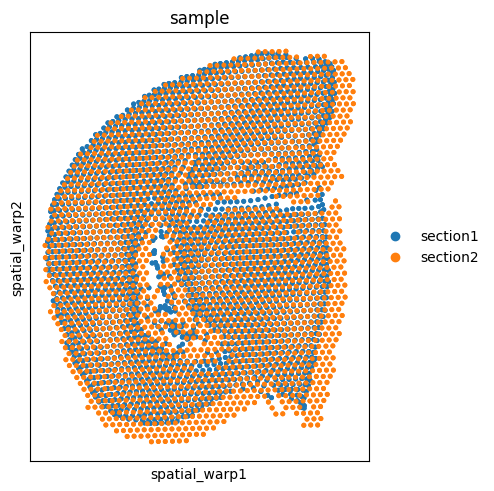

In [13]:
ap.align(reference="section2", key_added="spatial_warp")
sq.pl.spatial_scatter(
    adata, shape=None, spatial_key="spatial_warp", library_id="sample", color="sample"
)

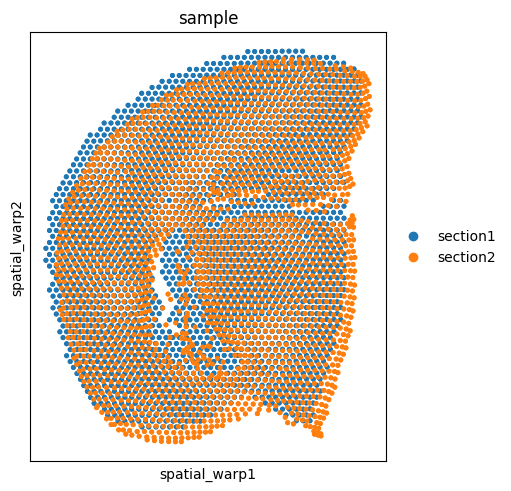

In [14]:
ap.align(reference="section1", key_added="spatial_warp")
sq.pl.spatial_scatter(
    adata, shape=None, spatial_key="spatial_warp", library_id="sample", color="sample"
)

#### Affine alignment

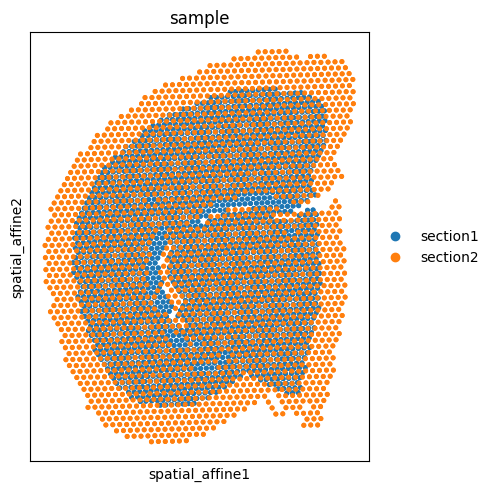

In [15]:
ap.align(reference="section2", mode="affine", key_added="spatial_affine")
sq.pl.spatial_scatter(
    adata, shape=None, spatial_key="spatial_affine", library_id="sample", color="sample"
)

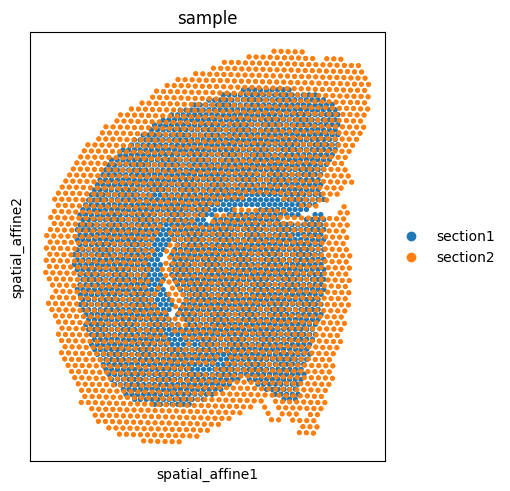

In [16]:
ap.align(reference="section1", mode="affine", key_added="spatial_affine")
sq.pl.spatial_scatter(
    adata, shape=None, spatial_key="spatial_affine", library_id="sample", color="sample"
)